only trying the kaggle data for now following https://www.youtube.com/watch?v=YncZ0WwxyzU

In [2]:
import pandas as pd 

In [3]:
df = pd.read_csv("sms/data/spam.csv", encoding="latin-1")
df.head()

,message,is_spam
0,"Go until jurong point, crazy.. Available only ...",False
1,Ok lar... Joking wif u oni...,False
2,Free entry in 2 a wkly comp to win FA Cup fina...,True
3,U dun say so early hor... U c already then say...,False
4,"Nah I don't think he goes to usf, he lives aro...",False


In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["is_spam"] = le.fit_transform(df["is_spam"])

In [5]:
df.head()

,message,is_spam
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


missing valas

In [6]:
df.isnull().sum()

message    0
is_spam    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(403)

In [8]:
df = df.drop_duplicates(keep="first")

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.shape

(5169, 2)

# EDA

In [11]:
df.value_counts("is_spam")

is_spam
0    4516
1     653
Name: count, dtype: int64

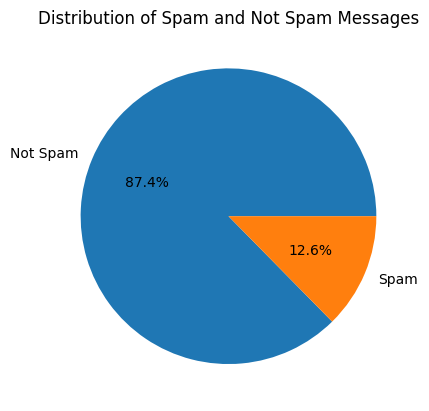

In [12]:
import matplotlib.pyplot as plt
plt.pie(df["is_spam"].value_counts(), labels=["Not Spam", "Spam"], autopct="%1.1f%%")
plt.title("Distribution of Spam and Not Spam Messages")
plt.show()


In [13]:
%pip install --upgrade nltk

Note: you may need to restart the kernel to use updated packages.


In [14]:
import nltk

nltk.download("punkt")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\adars\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [15]:
df["message_length"] = df["message"].apply(len)

In [16]:
df.head()

,message,is_spam,message_length
0,"Go until jurong point, crazy.. Available only ...",0,111
1,Ok lar... Joking wif u oni...,0,29
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,155
3,U dun say so early hor... U c already then say...,0,49
4,"Nah I don't think he goes to usf, he lives aro...",0,61


In [17]:
df["word_count"] = df["message"].apply(lambda x: len(nltk.word_tokenize(x)))

In [18]:
df.head()

,message,is_spam,message_length,word_count
0,"Go until jurong point, crazy.. Available only ...",0,111,24
1,Ok lar... Joking wif u oni...,0,29,8
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,37
3,U dun say so early hor... U c already then say...,0,49,13
4,"Nah I don't think he goes to usf, he lives aro...",0,61,15


In [19]:
df['num_sentences'] = df['message'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [20]:
df.head()

,message,is_spam,message_length,word_count,num_sentences
0,"Go until jurong point, crazy.. Available only ...",0,111,24,2
1,Ok lar... Joking wif u oni...,0,29,8,2
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,37,2
3,U dun say so early hor... U c already then say...,0,49,13,1
4,"Nah I don't think he goes to usf, he lives aro...",0,61,15,1


In [21]:
df[['num_sentences', 'word_count', 'message_length']].describe()

,num_sentences,word_count,message_length
count,5169.000000,5169.000000,5169.000000
mean,1.965564,18.455794,78.977945
std,1.448541,13.324758,58.236293
min,1.000000,1.000000,2.000000
25%,1.000000,9.000000,36.000000
50%,1.000000,15.000000,60.000000
75%,2.000000,26.000000,117.000000
max,38.000000,220.000000,910.000000


In [23]:
df[df["is_spam"] == 0][['num_sentences', 'word_count', 'message_length']].describe()

,num_sentences,word_count,message_length
count,4516.000000,4516.000000,4516.000000
mean,1.820195,17.123782,70.459256
std,1.383657,13.493970,56.358207
min,1.000000,1.000000,2.000000
25%,1.000000,8.000000,34.000000
50%,1.000000,13.000000,52.000000
75%,2.000000,22.000000,90.000000
max,38.000000,220.000000,910.000000


In [24]:
df[df["is_spam"] == 1][['num_sentences', 'word_count', 'message_length']].describe()


,num_sentences,word_count,message_length
count,653.000000,653.000000,653.000000
mean,2.970904,27.667688,137.891271
std,1.488425,7.008418,30.137753
min,1.000000,2.000000,13.000000
25%,2.000000,25.000000,132.000000
50%,3.000000,29.000000,149.000000
75%,4.000000,32.000000,157.000000
max,9.000000,46.000000,224.000000


In [26]:
%pip install seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


<Axes: ylabel='Count'>

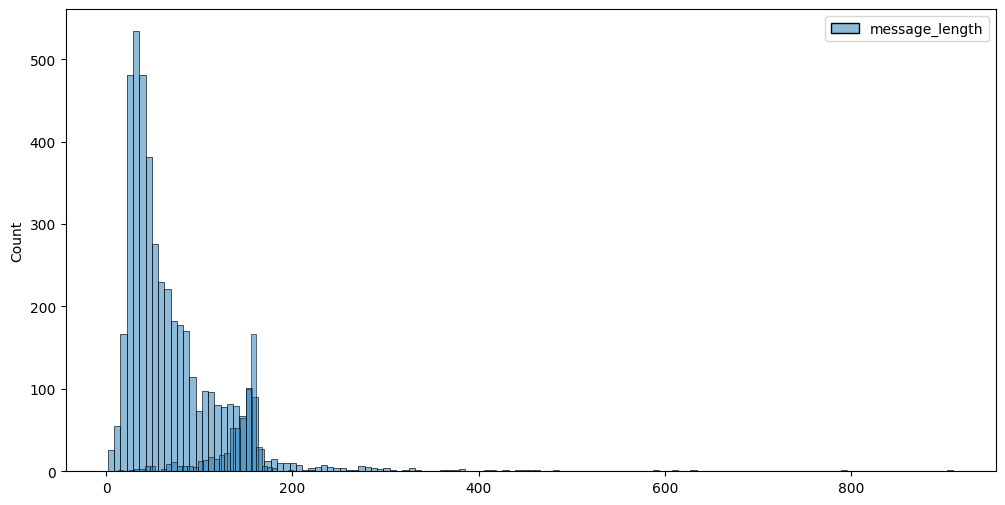

In [31]:
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.histplot(df[df["is_spam"] == 0][['message_length']], color="blue")
sns.histplot(df[df["is_spam"] == 1][['message_length']], color="red")


<Axes: ylabel='Count'>

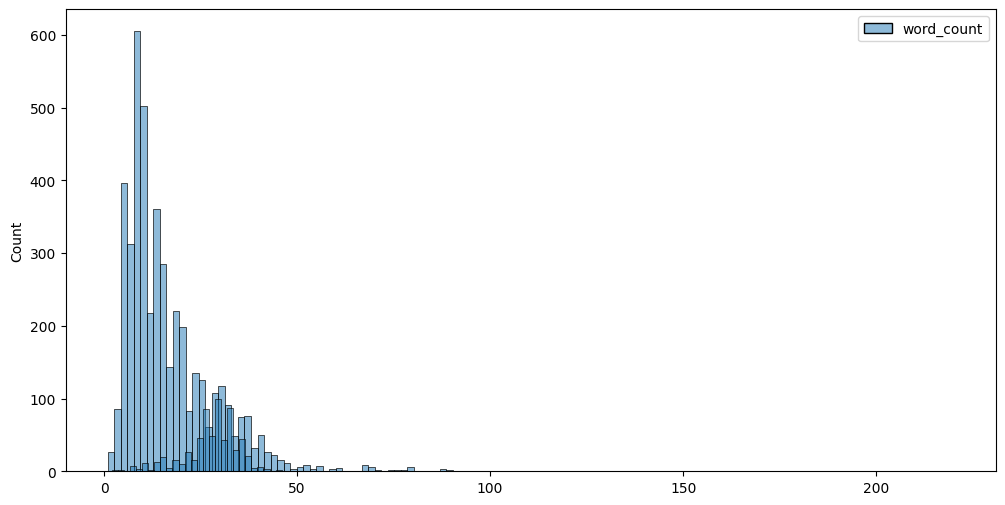

In [30]:
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.histplot(df[df["is_spam"] == 0][['word_count']])
sns.histplot(df[df["is_spam"] == 1][['word_count']], color="red")


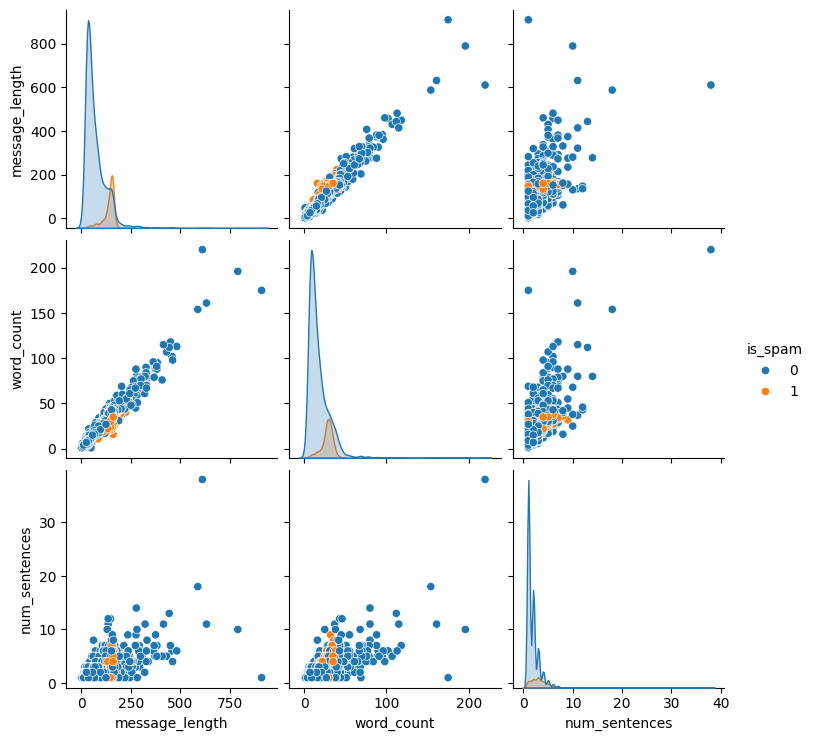

In [33]:
sns.pairplot(df, hue="is_spam")

In [40]:
corr = df[['is_spam','message_length','word_count','num_sentences']].corr()
corr

,is_spam,message_length,word_count,num_sentences
is_spam,1.000000,0.384717,0.262912,0.263939
message_length,0.384717,1.000000,0.965760,0.624139
word_count,0.262912,0.965760,1.000000,0.679971
num_sentences,0.263939,0.624139,0.679971,1.000000


<Axes: >

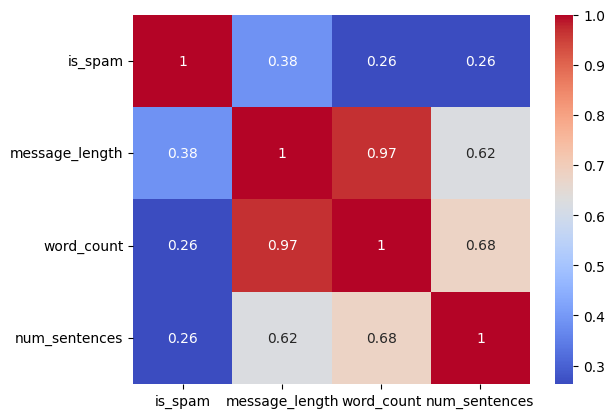

In [41]:
sns.heatmap(corr, annot=True, cmap="coolwarm")

# take num char as heights variation 

In [44]:
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
ps = PorterStemmer()
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    
            
    return " ".join(y)

In [45]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [47]:
df['message'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [48]:
df['transformed_text'] = df['message'].apply(transform_text)

In [49]:
df.head()

,message,is_spam,message_length,word_count,num_sentences,transformed_text
0,"Go until jurong point, crazy.. Available only ...",0,111,24,2,go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,0,29,8,2,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,0,49,13,1,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",0,61,15,1,nah think goe usf live around though


In [50]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [53]:
spam_wc = wc.generate(df[df['is_spam'] == 1]['transformed_text'].str.cat(sep=" "))

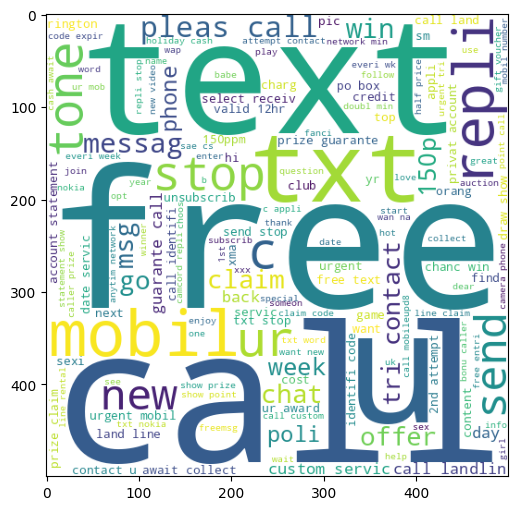

In [54]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)